In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    roc_auc_score, average_precision_score,
    brier_score_loss
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Metric helpers (binary + multiclass safe) ────────────────────────────────

def safe_roc_auc(y_true, y_proba):
    """
    ROC-AUC that works for both binary and multiclass.
    Binary     → pass only the positive-class column (sklearn requirement).
    Multiclass → OvR macro average.
    """
    classes = np.unique(y_true)
    if len(classes) == 2:
        return roc_auc_score(y_true, y_proba[:, 1])
    return roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')


def multiclass_pr_auc(y_true, y_proba):
    """Macro-averaged PR-AUC via one-vs-rest."""
    classes = np.unique(y_true)
    y_bin   = label_binarize(y_true, classes=classes)
    if y_bin.shape[1] == 1:          # binary edge-case from label_binarize
        y_bin = np.hstack([1 - y_bin, y_bin])
    # Clip probabilities to [0, 1] to handle floating-point precision issues
    y_proba = np.clip(y_proba, 0.0, 1.0)
    scores = [
        average_precision_score(y_bin[:, c], y_proba[:, c])
        for c in range(len(classes))
        if c < y_proba.shape[1]
    ]
    return float(np.mean(scores)) if scores else float('nan')


def multiclass_brier_score(y_true, y_proba):
    """Multiclass Brier score via one-vs-rest macro average."""
    classes = np.unique(y_true)
    y_bin   = label_binarize(y_true, classes=classes)
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    # Clip probabilities to [0, 1] to handle floating-point precision issues
    y_proba = np.clip(y_proba, 0.0, 1.0)
    scores = [
        brier_score_loss(y_bin[:, c], y_proba[:, c])
        for c in range(len(classes))
        if c < y_proba.shape[1]
    ]
    return float(np.mean(scores)) if scores else float('nan')


def expected_calibration_error(y_true, y_proba, n_bins=10):
    """
    Multiclass ECE via one-vs-rest decomposition.
    Buckets predicted probabilities into equal-width bins and computes
    |accuracy - confidence| weighted by bin fraction, averaged across classes.
    """
    classes = np.unique(y_true)
    y_bin   = label_binarize(y_true, classes=classes)
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    # Clip probabilities to [0, 1] to handle floating-point precision issues
    y_proba = np.clip(y_proba, 0.0, 1.0)
    bins    = np.linspace(0, 1, n_bins + 1)
    ece_vals = []
    for c in range(len(classes)):
        if c >= y_proba.shape[1]:
            continue
        prob_c = y_proba[:, c]
        true_c = y_bin[:, c]
        ece_c  = 0.0
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (prob_c >= lo) & (prob_c < hi)
            if mask.sum() == 0:
                continue
            ece_c += (mask.sum() / len(y_true)) * abs(true_c[mask].mean() - prob_c[mask].mean())
        ece_vals.append(ece_c)
    return float(np.mean(ece_vals)) if ece_vals else float('nan')

def ci_95(series):
    """
    95% confidence interval for the mean of a pandas Series or 1-D array,
    using the t-distribution (appropriate for small simulation counts).
    Returns (lower, upper).
    """
    from scipy.stats import t as t_dist
    n    = len(series)
    mean = np.mean(series)
    se   = np.std(series, ddof=1) / np.sqrt(n)
    h    = t_dist.ppf(0.975, df=n - 1) * se   # half-width
    return mean - h, mean + h

In [3]:
# %%
# ─────────────────────────────────────────────────────────────────────────────
# Theoretical Risk Functions  (Cover & Hart 1967 / Dist-KNN framework)
# ─────────────────────────────────────────────────────────────────────────────

def compute_r_star_x(model, X_query: pd.DataFrame) -> np.ndarray:
    """
    Conditional Bayes risk r*(x) at each query point x.

    For an M-class problem:
        r*(x) = 1 - max_c { q̂_c(x) }

    i.e. 1 minus the highest posterior class probability.
    This equals min(q̂₁, q̂₂) in the binary case.

    Parameters
    ----------
    model     : fitted GridSearchCV wrapping a KNeighborsClassifier (dictionary containing dist and prob model)
    X_query   : query points  (n_samples × n_features)

    Returns
    -------
    r_star : ndarray of shape (n_samples,)
    """
    prob_model = model['prob_model']
    q_hat = prob_model.predict_proba(X_query)          # (n_samples, n_classes)
    r_star = 1.0 - q_hat.max(axis=1)              # scalar per query point
    return r_star


def compute_R_star(model, X_query: pd.DataFrame) -> float:
    """
    Expected Bayes risk R* = E[r*(x)] for one machine,
    approximated by the sample mean over X_query.

    Parameters
    ----------
    model     : fitted GridSearchCV
    X_query   : held-out query points

    Returns
    -------
    R_star : float
    """
    return float(compute_r_star_x(model, X_query).mean())


def compute_mu_hat(model, X: pd.DataFrame) -> np.ndarray:
    """
    Proxy for μ(x): the model's predicted class probability vector at each point.
    Works for any number of classes — returns the full (n_samples, n_classes) matrix
    so that bias can be computed per class and then averaged into a scalar norm.

    Parameters
    ----------
    model : fitted GridSearchCV (dictionary for prob_model and dist_model)
    X     : feature matrix

    Returns
    -------
    mu_hat : ndarray of shape (n_samples, n_classes)
    """
    prob_model = model['prob_model']
    return prob_model.predict_proba(X)   # (n_samples, n_classes)


def compute_bias_vector(
    model,
    X_query: pd.DataFrame,
    K_i: int,
) -> np.ndarray:
    """
    Local bias for machine i, generalised to any number of classes:
        Bᵢ(x) = ‖μ(x) - (1/Kᵢ) Σⱼ μ(xᵢ,ⱼ)‖₂

    μ(x) is the full predicted class-probability vector (n_classes,).
    The per-class difference is averaged across classes via the L2 norm
    to produce a single scalar bias per query point, which is what the
    Dist-KNN covariance matrix C requires.

    Parameters
    ----------
    model   : fitted GridSearchCV (KNN inside)
    X_query : query points  (n_samples × n_features)
    K_i     : number of neighbours used by this machine

    Returns
    -------
    B_i : ndarray of shape (n_samples,)  — one scalar bias per query point
    """
    dist_model = model['dist_model']
    knn: KNeighborsClassifier = dist_model.best_estimator_

    # μ(x) — full probability vector at each query point: (n_samples, n_classes)
    mu_x = compute_mu_hat(model, X_query)

    # Retrieve the K_i nearest training-set neighbours for each query point
    distances, indices = knn.kneighbors(X_query, n_neighbors=K_i)

    # μ̂ at every training point: (n_train, n_classes)
    X_train_arr = knn._fit_X
    X_train_df  = pd.DataFrame(X_train_arr, columns=X_query.columns)
    mu_train    = compute_mu_hat(model, X_train_df)   # (n_train, n_classes)

    # Average μ over the K_i neighbours: indices is (n_samples, K_i)
    # mu_train[indices] → (n_samples, K_i, n_classes)
    mu_neighbour_means = mu_train[indices].mean(axis=1)  # (n_samples, n_classes)

    # Per-class difference, collapsed to a scalar via L2 norm — works for any n_classes
    B_i = np.linalg.norm(mu_x - mu_neighbour_means, axis=1)  # (n_samples,)
    return B_i


print("Theoretical risk functions defined.")

Theoretical risk functions defined.


In [4]:
def create_models(server_datasets):

    best_neighbors = []
    best_f1_scores = []
    model_instance_list = []
    dataset_sizes = []
        
    for df_train, df_test in (server_datasets):
        # Distance model: KNN with optimal K
        params_knn = {"n_neighbors": np.arange(3, 51, 2)}
        knn = KNeighborsClassifier()
        dist_model = GridSearchCV(knn, params_knn, scoring='f1_macro', cv=2, n_jobs=-1)
        
        # Classification model: Logistic Regression with moderate hyperparameter search
        lr = LogisticRegression(max_iter=1000, multi_class='multinomial')
        params_lr = {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'saga']
        }
        prob_model = GridSearchCV(lr, params_lr, scoring='f1_macro', cv=2, n_jobs=-1)
        
        X_s_train = df_train.drop(['y'], axis=1).values
        y_s_train = df_train['y'].values
        X_s_test = df_test.drop(['y'], axis=1).values
        y_s_test = df_test['y'].values

        # Train both models independently
        dist_model.fit(X_s_train, y_s_train)
        prob_model.fit(X_s_train, y_s_train)
        
        y_pred = prob_model.predict(X_s_test)
        
        best_neighbors.append(dist_model.best_params_['n_neighbors'])
        best_f1_scores.append(f1_score(y_s_test, y_pred, average='macro'))
        model_instance_list.append({
            'dist_model': dist_model,
            'prob_model': prob_model
        })
        
        dataset_sizes.append(df_train.shape[0])

    return (best_neighbors, best_f1_scores, model_instance_list, dataset_sizes)

In [5]:
class ModelPerformanceAnalyzer:
    def __init__(self, models, model_names=None):
        self.models = models
        self.model_names = model_names or [f"Model_{i}" for i in range(len(models))]
        self.performance_df = None

    def analyze_models(self, X_unseen, y_unseen):
        results = []
        for i, (model, name) in enumerate(zip(self.models, self.model_names)):
            model_metrics = self._analyze_single_model(
                model, name, i, X_unseen, y_unseen
            )
            results.append(model_metrics)
        self.performance_df = pd.DataFrame(results)
        return self.performance_df

    def _analyze_single_model(self, model, name, index, X_unseen, y_unseen):
        # Predictions and probabilities
        y_pred  = model['prob_model'].predict(X_unseen)
        y_proba = model['prob_model'].predict_proba(X_unseen)

        metrics = {
            'model_name'  : name,
            'model_index' : index,
            'f1_score'    : f1_score(y_unseen, y_pred, average='macro'),
            'roc_auc'     : safe_roc_auc(y_unseen, y_proba),
            'pr_auc'      : multiclass_pr_auc(y_unseen, y_proba),
            'brier_score' : multiclass_brier_score(y_unseen, y_proba),
            'ece'         : expected_calibration_error(y_unseen, y_proba),
            'classification_probabilities': y_proba.tolist()
        }

        distance_metrics = self._calculate_distance_metrics(model['dist_model'], X_unseen)
        metrics.update(distance_metrics)
        return metrics

    def _calculate_distance_metrics(self, model, X_unseen):
        """Calculate various distance-based metrics."""
        try:
            nbrs = model.best_estimator_
            distances, indices = nbrs.kneighbors(X_unseen)
            distances_no_self = distances

            point_medians = np.median(distances_no_self, axis=1)
            point_means   = np.mean(distances_no_self, axis=1)
            point_mins    = np.min(distances_no_self, axis=1)
            point_maxs    = np.max(distances_no_self, axis=1)

            return {
                'median_distance_all_points': np.median(point_medians),
                'mean_distance_all_points'  : np.mean(point_means),
                'min_distance_all_points'   : np.min(point_mins),
                'max_distance_all_points'   : np.max(point_maxs),
                'distance_std'              : np.std(distances_no_self),
            }
        except Exception as e:
            warnings.warn(f"Distance calculation failed for model: {e}")
            return {
                'median_distance_all_points': np.nan,
                'mean_distance_all_points'  : np.nan,
                'min_distance_all_points'   : np.nan,
                'max_distance_all_points'   : np.nan,
                'distance_std'              : np.nan,
            }

    def get_probability_matrix(self, model_index):
        """Get probability matrix for a specific model as numpy array."""
        if self.performance_df is not None:
            return np.array(self.performance_df.loc[model_index, 'classification_probabilities'])
        return None

    def get_all_probabilities(self):
        """Get all probability matrices as a 3D array (models x samples x classes)."""
        if self.performance_df is not None:
            return np.array([np.array(probs) for probs in self.performance_df['classification_probabilities']])
        return None


In [6]:
def run_distributed_knn_simulation(data_train, data_test, n_simulations=10, n_servers=100, test_size=0.2):
    """
    Optimized version using ModelPerformanceAnalyzer for probability extraction
    """
    import scipy.linalg as la

    simulation_results = []
    all_medians = []
    all_means = []

    for sim in range(n_simulations):
        print(f"Running simulation {sim+1}/{n_simulations}")

        # 1. Split data
        X_train_full   = data_train.drop(['y'], axis=1)
        y_train_full   = data_train['y']
        X_test_heldout = data_test.drop(['y'], axis=1)
        y_test_heldout = data_test['y']

        # 2. Generate server datasets
        def generate_server_datasets(train_pool, test_pool, n_servers=100,
                                    min_samples=1000, max_samples=5000):
            """
            Plain random (non-stratified) sampling — each server gets a random
            subset of varying size, so class distributions will naturally vary
            across servers. This is the condition our distance-weighting is
            designed to handle.
            """
            server_datasets = []
            n_train_pool    = len(train_pool)
            n_test_pool     = len(test_pool)

            for seed in range(n_servers):
                rng = np.random.default_rng(seed)

                train_size   = rng.integers(min_samples, max_samples)
                train_idx    = rng.choice(n_train_pool, size=train_size, replace=False)
                server_train = train_pool.iloc[train_idx]

                test_size_s = int(0.3 * train_size)
                test_idx    = rng.choice(n_test_pool, size=test_size_s, replace=False)
                server_test = test_pool.iloc[test_idx]

                server_datasets.append((server_train, server_test))

            return server_datasets

        train_pool_df = pd.concat([X_train_full, y_train_full], axis=1)
        test_pool_df  = pd.concat([X_test_heldout, y_test_heldout], axis=1)

        min_samples = int(0.05 * len(train_pool_df))
        max_samples = int(0.4 * len(train_pool_df))

        server_datasets = generate_server_datasets(
            train_pool_df, test_pool_df, n_servers, min_samples, max_samples
        )

        # 3. Train models
        best_neighbors, best_f1_scores, model_instance_list, dataset_sizes = create_models(server_datasets)

        metrics_df = pd.DataFrame({
            'optimal_k_value': best_neighbors,
            'best_f1_scores' : best_f1_scores,
            'model_instance' : model_instance_list,
            'dataset_size'   : dataset_sizes
        })
        metrics_df = metrics_df[metrics_df['best_f1_scores'] != 0].reset_index(drop=True)

        # 4. Test on held-out data
        n_test_samples = min(500, len(X_test_heldout))
        test_indices   = np.random.choice(len(X_test_heldout), size=n_test_samples, replace=False)
        X_test_samples = X_test_heldout.iloc[test_indices]
        y_test_true    = y_test_heldout.iloc[test_indices]

        # Use ModelPerformanceAnalyzer to get all metrics and probabilities
        analyzer    = ModelPerformanceAnalyzer(metrics_df['model_instance'].tolist())
        analysis_df = analyzer.analyze_models(X_test_samples, y_test_true)

        # Merge results
        metrics_df = metrics_df.merge(
            analysis_df[['model_index', 'median_distance_all_points', 'mean_distance_all_points']],
            left_index=True,
            right_on='model_index'
        ).reset_index(drop=True)

        all_medians.extend(metrics_df['median_distance_all_points'].tolist())
        all_means.extend(metrics_df['mean_distance_all_points'].tolist())

        # 5. Define scoring functions
        def arctan_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 0.5 + (np.arctan(((max_d + min_d)/2) - distance) / np.pi)

        def tanh_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 0.5 + 0.5 * (np.tanh(((max_d + min_d)/2) - distance))

        def sigmoid_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 1 / (1 + 2 * np.exp(((max_d + min_d)/2) - distance))

        def relu_score(distance, df):
            mean      = df['median_distance_all_points'].mean()
            deviation = df['median_distance_all_points'].std()
            upper     = mean + 2 * deviation
            lower     = mean - 2 * deviation

            if distance > upper or distance < lower:
                return 0

            # Original relu: peaks at upper, higher weight for lower distance
            return upper - distance

        metrics_df['arctan_score']  = metrics_df['median_distance_all_points'].apply(lambda x: arctan_score(x, metrics_df))
        metrics_df['tanh_score']    = metrics_df['median_distance_all_points'].apply(lambda x: tanh_score(x, metrics_df))
        metrics_df['sigmoid_score'] = metrics_df['median_distance_all_points'].apply(lambda x: sigmoid_score(x, metrics_df))
        metrics_df['relu_score']    = metrics_df['median_distance_all_points'].apply(lambda x: relu_score(x, metrics_df))

        # 6. Extract probabilities
        probability_list = []
        for i in range(len(X_test_samples)):
            point_probs = []
            for model_idx in range(len(metrics_df)):
                model_probs = analyzer.get_probability_matrix(model_idx)
                point_probs.append(model_probs[i])
            probability_list.append(point_probs)
        probability_list = np.array(probability_list)   # (n_query, M, n_classes)

        # 7. Theoretical risk quantities — computed BEFORE aggregation so W* can be used
        sim_models = metrics_df['model_instance'].tolist()
        sim_K_list = metrics_df['optimal_k_value'].tolist()
        M_sim      = len(sim_models)
        n_q        = len(X_test_samples)

        def _r_star_x(model, X):
            """r*(x) = 1 - max_c q̂_c(x)  — works for any number of classes."""
            return 1.0 - model['prob_model'].predict_proba(X).max(axis=1)

        # CHANGED: renamed from _bias_scalar_ols to _bias_scalar_gwls
        def _bias_scalar_gwls(model, X_query, K_i):
            """
            Scalar spatial bias bᵢ using Gaussian-kernel Weighted Least Squares (GWLS).

            Instead of uniform OLS, each neighbour xᵢ,ⱼ is weighted by:
                wⱼ = exp(-dᵢ,ⱼ² / h²)   where h = median(dᵢ,₀, …, dᵢ,K-1)

            Using the server's own median distance as bandwidth h means:
            - Servers with tight neighbourhoods (low median) → large weights, sharp gradient
            - Servers with diffuse neighbourhoods (high median) → small weights, gradient pulled toward zero
            - Outlier neighbours at large distances are suppressed automatically

            Everything else (median displacement vector, b = g · d) is unchanged.
            """
            knn        = model['dist_model'].best_estimator_
            prob_model = model['prob_model']
            X_train    = knn._fit_X
            X_q_arr    = X_query.values

            X_train_df  = pd.DataFrame(X_train, columns=X_query.columns)
            p_train     = prob_model.predict_proba(X_train_df)

            distances, indices = knn.kneighbors(X_query, n_neighbors=K_i)

            b_scalars = []
            for q_idx in range(n_q):
                xq       = X_q_arr[q_idx]
                nbr_idx  = indices[q_idx]
                nbr_dist = distances[q_idx]

                X_nbr    = X_train[nbr_idx]
                p_nbr    = p_train[nbr_idx]

                pred_class  = np.argmax(p_nbr.mean(axis=0))
                p_target    = p_nbr[:, pred_class]

                X_mean   = X_nbr.mean(axis=0)
                p_mean   = p_target.mean()
                Xi_c     = X_nbr - X_mean
                yi_c     = p_target - p_mean

                # CHANGED: replace uniform OLS with Gaussian kernel weights
                # h = median distance for this server/query — self-normalising bandwidth
                h        = np.median(nbr_dist) + 1e-8
                gk_w     = np.exp(-(nbr_dist ** 2) / (h ** 2))   # (K_i,) kernel weights
                W_diag   = np.diag(gk_w)

                # CHANGED: WLS normal equations: (XᵀWX + λI)⁻¹ XᵀW ỹ
                XtWX     = Xi_c.T @ W_diag @ Xi_c + 1e-6 * np.eye(Xi_c.shape[1])
                XtWy     = Xi_c.T @ (gk_w * yi_c)
                g_i      = np.linalg.solve(XtWX, XtWy)
                # END CHANGED

                med_idx  = np.argmin(np.abs(nbr_dist - np.median(nbr_dist)))
                d_i      = X_nbr[med_idx] - xq

                b_scalars.append(float(g_i @ d_i))

            return float(np.mean(b_scalars))

        # r*(x) and R* per server
        r_star_x_list, R_star_list = [], []
        for model in sim_models:
            r_x = _r_star_x(model, X_test_samples)
            r_star_x_list.append(r_x)
            R_star_list.append(float(r_x.mean()))

        r_star_matrix = np.stack(r_star_x_list, axis=0)   # (M, n_query)
        R_star_vec    = np.array(R_star_list)              # (M,)

        # bᵢ — paper-exact OLS scalar bias using median displacement (one scalar per server)
        # This is the quantity the paper says each client transmits (O(1) communication).
        b_vec = np.array([
            _bias_scalar_gwls(model, X_test_samples, K_i)
            for model, K_i in zip(sim_models, sim_K_list)
        ])  # (M,)

        # C = b bᵀ — rank-1 outer product as defined in Theorem 2 of the paper
        C = np.outer(b_vec, b_vec)                         # (M, M)

        # V diagonal: Vᵢᵢ = R*ᵢ / Kᵢ
        V = np.diag(R_star_vec / np.array(sim_K_list, dtype=float))

        # Optimal W* via Sherman-Morrison (paper Section V, closed form)
        #   W* = (V+C)⁻¹ 1 / (1ᵀ (V+C)⁻¹ 1)
        # Pre-compute scalar sums for the Sherman-Morrison expansion
        K_vec  = np.array(sim_K_list, dtype=float)
        V_inv_diag = K_vec / R_star_vec                    # diagonal of V⁻¹
        S11    = np.sum(V_inv_diag)                        # 1ᵀ V⁻¹ 1
        Sb1    = float(b_vec @ V_inv_diag)                 # bᵀ V⁻¹ 1
        Sbb    = float(b_vec @ (V_inv_diag * b_vec))       # bᵀ V⁻¹ b

        denom_sm = S11 - (Sb1 ** 2) / (1.0 + Sbb)        # scalar denominator
        # Numerator: w*ᵢ ∝ (Kᵢ/R*ᵢ) · (1 − bᵢ · Sb1/(1+Sbb))
        num_vec  = V_inv_diag * (1.0 - b_vec * Sb1 / (1.0 + Sbb))
        W_star   = num_vec / denom_sm                      # (M,) — sums to 1 by construction

        # Clamp any numerically negative weights to zero and renormalise
        # W_star   = np.clip(W_star, 0.0, None)
        # W_star  /= W_star.sum()
        
        W_star = softmax(W_star)

        # Optimal R = R* + 1 / (1ᵀ (V+C)⁻¹ 1)  (Sherman-Morrison form)
        R_global_mean = float(R_star_vec.mean())
        R_optimal     = R_global_mean + 1.0 / denom_sm

        # Keep B_matrix for visualisation (store per-server bias scalar broadcast to n_query shape)
        B_matrix = b_vec[:, None] * np.ones((M_sim, n_q))  # (M, n_query) — constant per server

        # 8. Weighted predictions — approaches 1–5 (heuristic) + approach 6 (optimal W*)
        approaches = {
            'approach_1': 'arctan_score',
            'approach_2': 'dataset_size',
            'approach_3': 'tanh_score',
            'approach_4': 'sigmoid_score',
            'approach_5': 'relu_score'
        }

        approach_preds = {}
        for approach_name, weight_col in approaches.items():
            weights = metrics_df[weight_col].values
            weighted_results = []
            for probability in probability_list:
                weighted = probability * weights.reshape(-1, 1)
                weighted_results.append(weighted.sum(axis=0) / weights.sum())
            approach_preds[approach_name] = np.array([np.argmax(p) for p in weighted_results])

        # Approach 6 — optimal W* (already sums to 1, no normalisation needed)
        weighted_results_wstar = []
        for probability in probability_list:
            weighted = probability * W_star.reshape(-1, 1)   # (M, n_classes)
            weighted_results_wstar.append(weighted.sum(axis=0))
        approach_preds['approach_6'] = np.array([np.argmax(p) for p in weighted_results_wstar])

        # 9. Calculate metrics for all approaches
        # -- build weighted probability arrays (needed for prob-based metrics) --
        approach_probas = {}
        for approach_name, weight_col in approaches.items():
            weights = metrics_df[weight_col].values
            wp = np.array([
                (prob * weights.reshape(-1, 1)).sum(axis=0) / weights.sum()
                for prob in probability_list
            ])  # (n_query, n_classes)
            approach_probas[approach_name] = wp
        # W* probabilities
        approach_probas['approach_6'] = np.array([
            (prob * W_star.reshape(-1, 1)).sum(axis=0)
            for prob in probability_list
        ])

        sim_result = {'simulation': sim}
        for approach_name, preds in approach_preds.items():
            wp = approach_probas[approach_name]          # (n_query, n_classes)
            sim_result[f'{approach_name}_f1']       = f1_score(y_test_true, preds, average='macro')
            sim_result[f'{approach_name}_acc']      = accuracy_score(y_test_true, preds)
            sim_result[f'{approach_name}_roc_auc']  = safe_roc_auc(y_test_true, wp)
            sim_result[f'{approach_name}_pr_auc']   = multiclass_pr_auc(y_test_true, wp)
            sim_result[f'{approach_name}_brier']    = multiclass_brier_score(y_test_true, wp)
            sim_result[f'{approach_name}_ece']      = expected_calibration_error(y_test_true, wp)

        sim_result.update({
            'n_servers'          : len(metrics_df),
            'avg_dataset_size'   : metrics_df['dataset_size'].mean(),
            'avg_median_distance': metrics_df['median_distance_all_points'].mean(),
            # Theoretical quantities
            'r_star_per_server'  : R_star_list,
            'r_star_x_matrix'    : r_star_matrix.tolist(),
            'bias_matrix'        : B_matrix.tolist(),
            'C_matrix'           : C.tolist(),
            'V_diag'             : np.diag(V).tolist(),
            'W_star'             : W_star.tolist(),
            'mean_R_star'        : R_global_mean,
            'min_R_star'         : float(R_star_vec.min()),
            'max_R_star'         : float(R_star_vec.max()),
            'optimal_R'          : R_optimal,
        })

        simulation_results.append(sim_result)

    results_df = pd.DataFrame(simulation_results)
    return results_df, all_medians, all_means

In [7]:
# %%
# Load your data
# data_train = pd.read_csv('/kaggle/input/datasets/abhirajraje/oelp-dataset/news_preprocessed_train.csv')
# data_test = pd.read_csv('/kaggle/input/datasets/abhirajraje/oelp-dataset/news_preprocessed_test.csv')

data_train = pd.read_csv('../data/letter_preprocessed_train.csv')
data_test = pd.read_csv('../data/letter_preprocessed_test.csv')

# Run multiple simulations
results_df, all_medians, all_means = run_distributed_knn_simulation(data_train, data_test, n_simulations=50, n_servers=10)

Running simulation 1/50
Running simulation 2/50
Running simulation 3/50
Running simulation 4/50
Running simulation 5/50
Running simulation 6/50
Running simulation 7/50
Running simulation 8/50
Running simulation 9/50
Running simulation 10/50
Running simulation 11/50
Running simulation 12/50
Running simulation 13/50
Running simulation 14/50
Running simulation 15/50
Running simulation 16/50
Running simulation 17/50
Running simulation 18/50
Running simulation 19/50
Running simulation 20/50
Running simulation 21/50
Running simulation 22/50
Running simulation 23/50
Running simulation 24/50
Running simulation 25/50
Running simulation 26/50
Running simulation 27/50
Running simulation 28/50
Running simulation 29/50
Running simulation 30/50
Running simulation 31/50
Running simulation 32/50
Running simulation 33/50
Running simulation 34/50
Running simulation 35/50
Running simulation 36/50
Running simulation 37/50
Running simulation 38/50
Running simulation 39/50
Running simulation 40/50
Running s

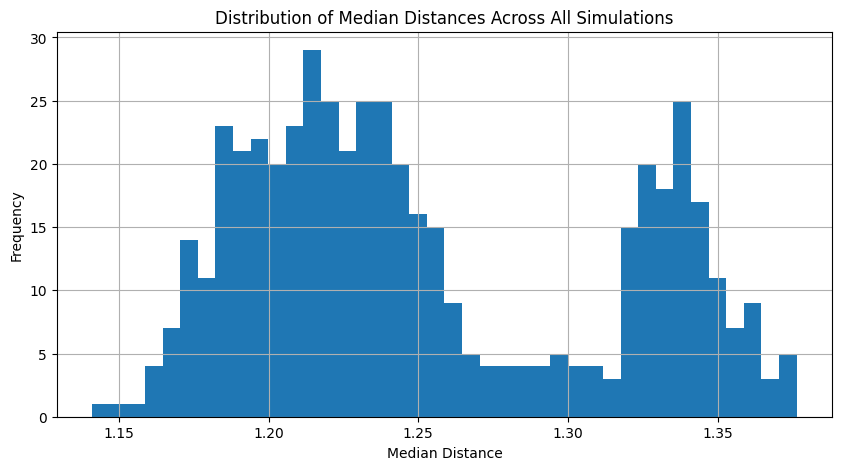

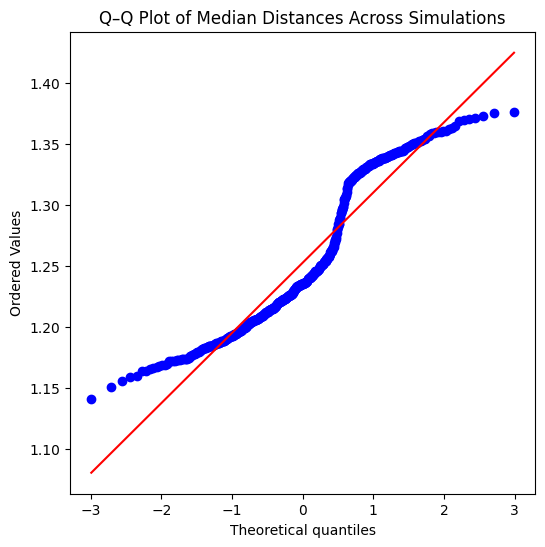

In [8]:
import scipy.stats as stats

plt.figure(figsize=(10, 5))
plt.hist(all_medians, bins=40)
plt.title('Distribution of Median Distances Across All Simulations')
plt.xlabel('Median Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(all_medians, dist="norm", plot=plt)
plt.title('Q–Q Plot of Median Distances Across Simulations')
plt.show()

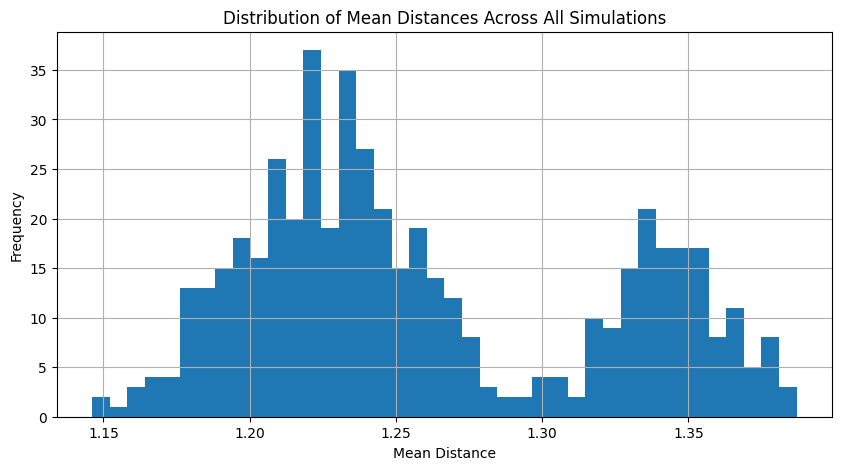

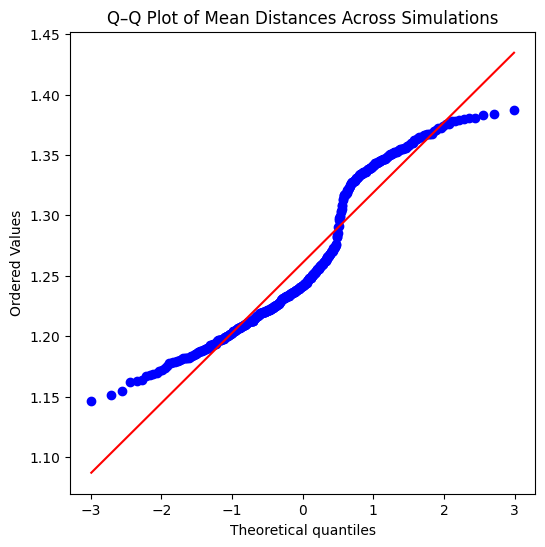

In [9]:
import scipy.stats as stats

plt.figure(figsize=(10, 5))
plt.hist(all_means, bins=40)
plt.title('Distribution of Mean Distances Across All Simulations')
plt.xlabel('Mean Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(all_means, dist="norm", plot=plt)
plt.title('Q–Q Plot of Mean Distances Across Simulations')
plt.show()

In [10]:
# Find the best Logistic Regression on overall data (distance model: KNN, classification model: LR)
X_train = data_train.drop(['y'], axis=1)
y_train = data_train['y']
X_test  = data_test.drop(['y'], axis=1)
y_test  = data_test['y']

# Distance model: KNN
params_knn = {"n_neighbors": np.arange(3, 31, 2)}
knn = KNeighborsClassifier()
dist_model_benchmark = GridSearchCV(knn, params_knn, scoring='f1_macro', cv=2, n_jobs=-1)

# Classification model: Logistic Regression (same parameters as in create_models)
lr = LogisticRegression(max_iter=1000, multi_class='multinomial')
params_lr = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'saga']
}
prob_model_benchmark = GridSearchCV(lr, params_lr, scoring='f1_macro', cv=2, n_jobs=-1)

# Train both models
dist_model_benchmark.fit(X_train, y_train)
prob_model_benchmark.fit(X_train, y_train)

y_pred  = prob_model_benchmark.predict(X_test)
y_proba = prob_model_benchmark.predict_proba(X_test)

buffer_model = {"dist_model": dist_model_benchmark, "prob_model": prob_model_benchmark}

R_star_global_model = compute_R_star(buffer_model, X_test)
k_global_model      = dist_model_benchmark.best_params_['n_neighbors']
V_global_model      = R_star_global_model / k_global_model

print(classification_report(y_test, y_pred))
print(f"Best KNN Params: {dist_model_benchmark.best_params_}")
print(f"Best LR Params: {prob_model_benchmark.best_params_}")

benchmark_f1      = f1_score(y_test, y_pred, average='macro')
benchmark_roc_auc = safe_roc_auc(y_test, y_proba)
benchmark_pr_auc  = multiclass_pr_auc(y_test, y_proba)
benchmark_brier   = multiclass_brier_score(y_test, y_proba)
benchmark_ece     = expected_calibration_error(y_test, y_proba)

print(f"Best F1 Score:   {benchmark_f1:.4f}")
print(f"ROC-AUC (macro): {benchmark_roc_auc:.4f}")
print(f"PR-AUC (macro):  {benchmark_pr_auc:.4f}")
print(f"Brier Score:     {benchmark_brier:.4f}")
print(f"ECE:             {benchmark_ece:.4f}")

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       158
           1       0.67      0.73      0.70       153
           2       0.87      0.82      0.85       147
           3       0.79      0.80      0.79       161
           4       0.68      0.80      0.73       154
           5       0.74      0.77      0.75       155
           6       0.69      0.57      0.63       155
           7       0.59      0.51      0.55       147
           8       0.86      0.79      0.82       151
           9       0.85      0.83      0.84       149
          10       0.74      0.70      0.72       148
          11       0.80      0.82      0.81       152
          12       0.90      0.89      0.90       158
          13       0.83      0.83      0.83       157
          14       0.62      0.65      0.63       150
          15       0.85      0.81      0.83       161
          16       0.72      0.74      0.73       157
          17       0.70    

In [11]:
# %%
# Analyze results
from scipy.stats import t as t_dist

approaches_labels = {
    'approach_1': 'Arctan ',
    'approach_2': 'Size   ',
    'approach_3': 'Tanh   ',
    'approach_4': 'Sigmoid',
    'approach_5': 'ReLU   ',
    'approach_6': 'W*     ',
}

metrics_info = [
    ('F1 (macro)',  '_f1',      False),
    ('Accuracy',   '_acc',     False),
    ('ROC-AUC',    '_roc_auc', False),
    ('PR-AUC',     '_pr_auc',  False),
    ('Brier Score','_brier',   True),
    ('ECE',        '_ece',     True),
]

print("Simulation Results Summary")
print("=" * 80)
print(f"Number of simulations: {len(results_df)}")

for metric_name, suffix, lower_better in metrics_info:
    direction = '(↓ better)' if lower_better else '(↑ better)'
    print(f"\nAverage {metric_name} {direction}:")
    print(f"  {'Approach':<10} {'Mean':>8}  {'Std':>8}  {'95% CI':>22}")
    print(f"  {'-'*10}  {'-'*8}  {'-'*8}  {'-'*22}")
    for key, label in approaches_labels.items():
        col       = f'{key}{suffix}'
        vals      = results_df[col].dropna()
        mean      = vals.mean()
        std       = vals.std()
        lo, hi    = ci_95(vals)
        print(f"  {label:<10} {mean:>8.4f}  {std:>8.4f}  [{lo:>8.4f}, {hi:>8.4f}]")


Simulation Results Summary
Number of simulations: 50

Average F1 (macro) (↑ better):
  Approach       Mean       Std                  95% CI
  ----------  --------  --------  ----------------------
  Arctan       0.7680    0.0207  [  0.7621,   0.7739]
  Size         0.7686    0.0205  [  0.7628,   0.7744]
  Tanh         0.7680    0.0208  [  0.7620,   0.7739]
  Sigmoid      0.7689    0.0206  [  0.7630,   0.7747]
  ReLU         0.7701    0.0199  [  0.7644,   0.7758]
  W*           0.7685    0.0205  [  0.7626,   0.7743]

Average Accuracy (↑ better):
  Approach       Mean       Std                  95% CI
  ----------  --------  --------  ----------------------
  Arctan       0.7744    0.0199  [  0.7687,   0.7800]
  Size         0.7749    0.0196  [  0.7694,   0.7805]
  Tanh         0.7743    0.0199  [  0.7686,   0.7799]
  Sigmoid      0.7753    0.0196  [  0.7697,   0.7809]
  ReLU         0.7763    0.0191  [  0.7709,   0.7817]
  W*           0.7748    0.0197  [  0.7693,   0.7804]

Average RO

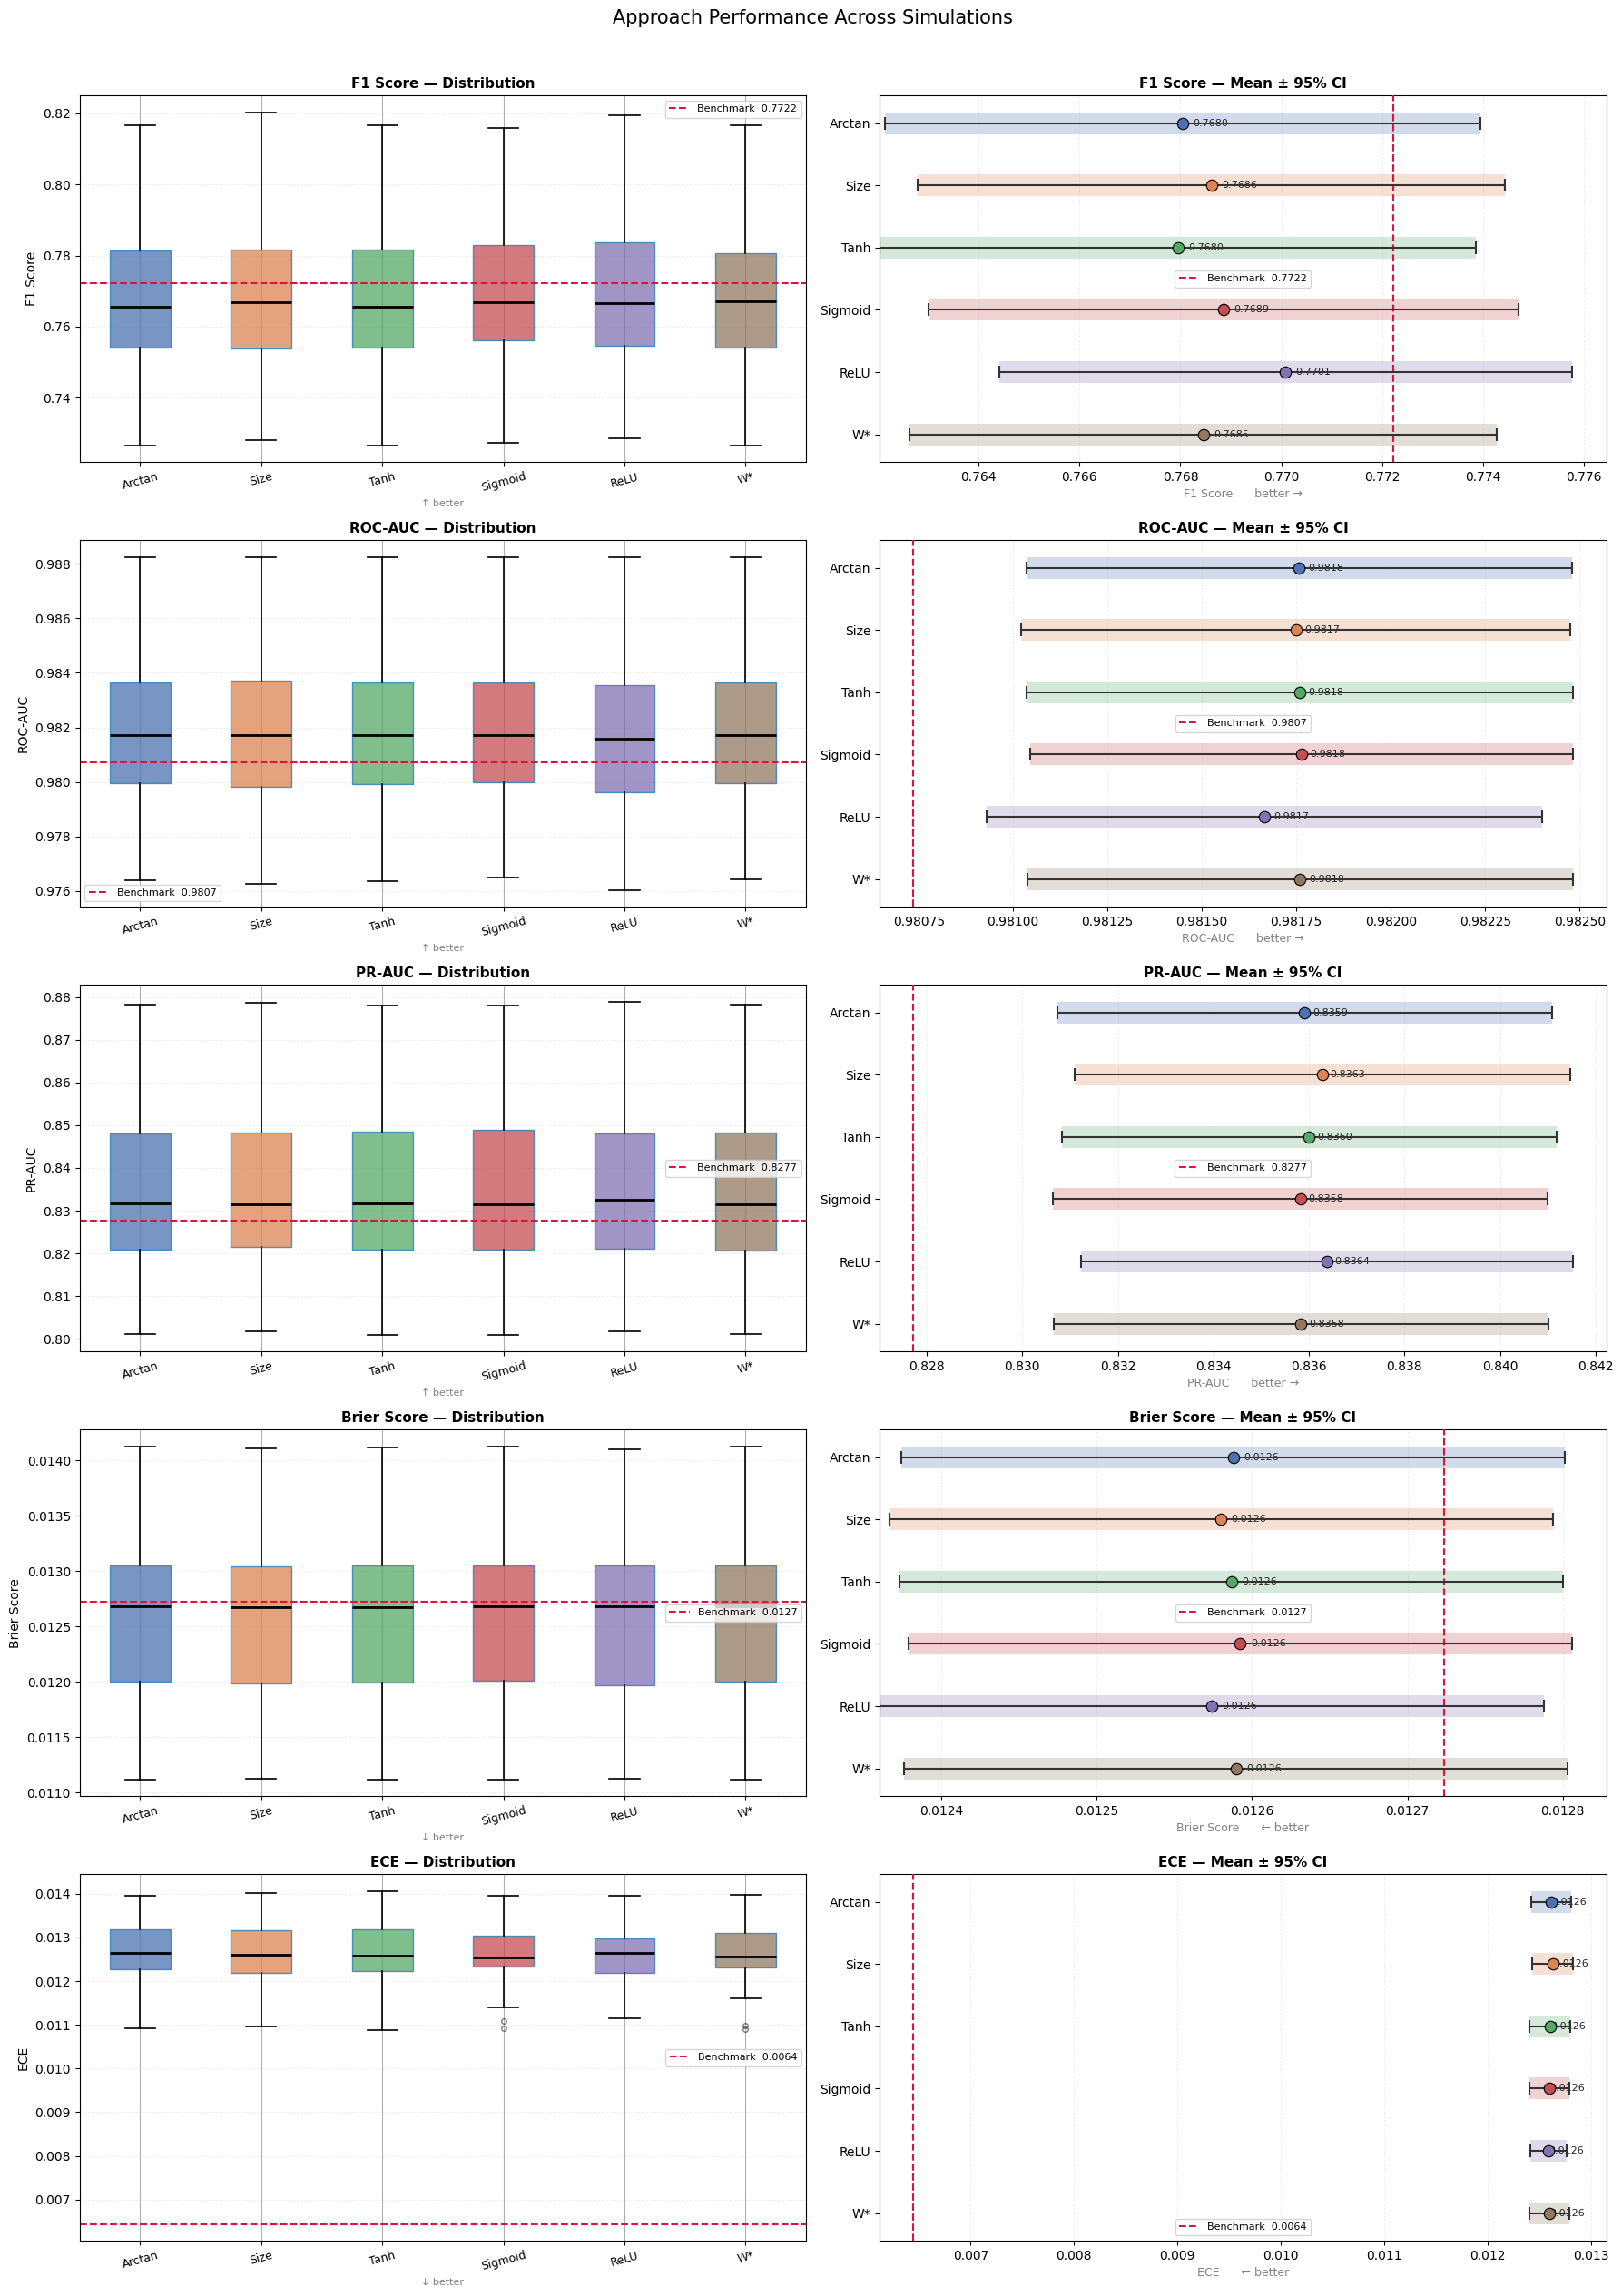

In [12]:
# %%
# Visualization — F1, ROC-AUC, PR-AUC, Brier Score, ECE
# Left:  boxplot across simulations
# Right: grouped mean ± 95% CI — one chart per metric, all approaches side-by-side
approach_labels = ['Arctan', 'Size', 'Tanh', 'Sigmoid', 'ReLU', 'W*']
colors          = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

plot_specs = [
    ('F1 Score',    '_f1',      benchmark_f1,      False),
    ('ROC-AUC',     '_roc_auc', benchmark_roc_auc, False),
    ('PR-AUC',      '_pr_auc',  benchmark_pr_auc,  False),
    ('Brier Score', '_brier',   benchmark_brier,   True),
    ('ECE',         '_ece',     benchmark_ece,     True),
]

fig, axes = plt.subplots(len(plot_specs), 2, figsize=(18, 5 * len(plot_specs)))
fig.suptitle('Approach Performance Across Simulations', fontsize=15, y=1.01)

for row, (metric_name, suffix, benchmark_val, lower_better) in enumerate(plot_specs):
    cols = [f'approach_{i}{suffix}' for i in range(1, 7)]

    # ── Left: boxplot ────────────────────────────────────────────────────────
    ax = axes[row, 0]
    bp = results_df[cols].boxplot(
        ax=ax, patch_artist=True, return_type='dict',
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f'{metric_name} — Distribution', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=10)
    ax.axhline(y=benchmark_val, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Benchmark  {benchmark_val:.4f}')
    ax.set_xticklabels(approach_labels, rotation=15, fontsize=9)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')
    ax.set_xlabel('↓ better' if lower_better else '↑ better', fontsize=8, color='grey')

    # ── Right: mean + 95% CI (horizontal lollipop chart) ────────────────────
    ax = axes[row, 1]
    means, lo_errs, hi_errs, ci_los, ci_his = [], [], [], [], []
    for col in cols:
        vals   = results_df[col].dropna()
        mean   = vals.mean()
        lo, hi = ci_95(vals)
        means.append(mean)
        lo_errs.append(mean - lo)
        hi_errs.append(hi - mean)
        ci_los.append(lo)
        ci_his.append(hi)

    y     = np.arange(len(approach_labels))
    means = np.array(means)

    # Horizontal CI spans
    for i, (lo, hi, color) in enumerate(zip(ci_los, ci_his, colors)):
        ax.barh(i, hi - lo, left=lo, height=0.35, color=color, alpha=0.25)

    # Mean dots
    for i, (mean, color) in enumerate(zip(means, colors)):
        ax.plot(mean, i, 'o', color=color, markersize=9, zorder=5,
                markeredgecolor='black', markeredgewidth=0.8)

    # CI whiskers
    ax.errorbar(means, y,
                xerr=[lo_errs, hi_errs],
                fmt='none', color='#333333', capsize=5,
                linewidth=1.5, capthick=1.5, zorder=4)

    # Benchmark line
    ax.axvline(x=benchmark_val, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Benchmark  {benchmark_val:.4f}', zorder=3)

    # Value labels on the dots
    x_range = max(ci_his) - min(ci_los)
    offset  = x_range * 0.015
    for i, mean in enumerate(means):
        ax.text(mean + offset, i, f'{mean:.4f}',
                va='center', ha='left', fontsize=8, color='#222222')

    ax.set_yticks(y)
    ax.set_yticklabels(approach_labels, fontsize=10)
    ax.set_xlabel(metric_name, fontsize=10)
    ax.set_title(f'{metric_name} — Mean ± 95% CI', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, axis='x', alpha=0.3, linestyle=':')
    ax.invert_yaxis()   # W* at top, Arctan at bottom — matches natural reading order
    direction_label = '← better' if lower_better else 'better →'
    ax.set_xlabel(f'{metric_name}      {direction_label}', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('approach_metrics_overview.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# %%
# Statistical significance testing
from scipy.stats import ttest_rel, t as t_dist

# ── Pairwise F1 t-tests ──────────────────────────────────────────────────────
pairs = [
    ('Arctan',  'approach_1', 'Size',    'approach_2'),
    ('Arctan',  'approach_1', 'Tanh',    'approach_3'),
    ('Size',    'approach_2', 'Tanh',    'approach_3'),
    ('Size',    'approach_2', 'Sigmoid', 'approach_4'),
    ('Tanh',    'approach_3', 'Sigmoid', 'approach_4'),
    ('Arctan',  'approach_1', 'Sigmoid', 'approach_4'),
]

print("Pairwise t-tests (F1 score):")
print(f"  {'Comparison':<22} {'p-value':>8}  {'95% CI on Δ':>26}")
print(f"  {'-'*22}  {'-'*8}  {'-'*26}")
for lA, kA, lB, kB in pairs:
    diff     = results_df[f'{kA}_f1'] - results_df[f'{kB}_f1']
    t, p     = ttest_rel(results_df[f'{kA}_f1'], results_df[f'{kB}_f1'])
    lo, hi   = ci_95(diff)
    label    = f'{lA} vs {lB}'
    print(f"  {label:<22} {p:>8.4f}  [{lo:>+9.4f}, {hi:>+9.4f}]")

# ── W* vs ReLU equivalence across all metrics ────────────────────────────────
metric_tests = [
    ('F1 Score',    '_f1',      False),
    ('ROC-AUC',     '_roc_auc', False),
    ('PR-AUC',      '_pr_auc',  False),
    ('Brier Score', '_brier',   True),
    ('ECE',         '_ece',     True),
]

print("\n── W* vs ReLU equivalence (paired t-test, two-tailed, α=0.05) ──")
print(f"{'Metric':<14} {'t-stat':>8}  {'p-value':>8}  {'Mean Δ':>9}  {'95% CI on Δ':>26}  {'Verdict'}")
print("-" * 85)
alpha     = 0.05
all_equiv = True
for metric_name, suffix, lower_better in metric_tests:
    col_wstar = f'approach_6{suffix}'
    col_relu  = f'approach_5{suffix}'
    diff      = results_df[col_wstar] - results_df[col_relu]
    t, p      = ttest_rel(results_df[col_wstar], results_df[col_relu])
    delta     = diff.mean()
    lo, hi    = ci_95(diff)
    equiv     = p > alpha
    if not equiv:
        all_equiv = False
    verdict = 'equivalent' if equiv else 'DIFFERENT'
    print(f"{metric_name:<14} {t:>8.4f}  {p:>8.4f}  {delta:>+9.4f}  [{lo:>+9.4f}, {hi:>+9.4f}]  {verdict}")

print()
if all_equiv:
    print("→ W* is statistically as good an approximation as ReLU on ALL metrics.")
else:
    print("→ W* and ReLU differ significantly on at least one metric.")


Pairwise t-tests (F1 score):
  Comparison              p-value                 95% CI on Δ
  ----------------------  --------  --------------------------
  Arctan vs Size           0.1023  [  -0.0013,   +0.0001]
  Arctan vs Tanh           0.4088  [  -0.0001,   +0.0003]
  Size vs Tanh             0.0523  [  -0.0000,   +0.0013]
  Size vs Sigmoid          0.5594  [  -0.0011,   +0.0006]
  Tanh vs Sigmoid          0.0014  [  -0.0014,   -0.0004]
  Arctan vs Sigmoid        0.0040  [  -0.0013,   -0.0003]

── W* vs ReLU equivalence (paired t-test, two-tailed, α=0.05) ──
Metric           t-stat   p-value     Mean Δ                 95% CI on Δ  Verdict
-------------------------------------------------------------------------------------
F1 Score        -2.6611    0.0105    -0.0016  [  -0.0029,   -0.0004]  DIFFERENT
ROC-AUC          4.3042    0.0001    +0.0001  [  +0.0001,   +0.0001]  DIFFERENT
PR-AUC          -2.5790    0.0130    -0.0005  [  -0.0010,   -0.0001]  DIFFERENT
Brier Score      4.1309 

## Theoretical Risk Analysis (Cover & Hart, 1967 + Dist-KNN)

The following cells compute the theoretical quantities from the Dist-KNN paper:

- **r\*(x)**: Conditional Bayes risk at point x — `min(q̂₁(x), q̂₂(x))` for binary classification  
- **R\***: Expected Bayes risk for each machine — `E[r*(x)]`  
- **Bᵢ(x)**: Local bias for machine i — `μ(x) − (1/Kᵢ) Σ μ(xᵢ,ⱼ)`  
- **C**: Uncentered covariance matrix where `C[i,j] = E[Bᵢ(x) Bⱼ(x)]`  
- **R**: Optimal aggregated risk under MSE — `R* + 1 / (1ᵀ (V+C)⁻¹ 1)`